MC Call price ~ 7.1116
MC Put  price ~ 9.0355


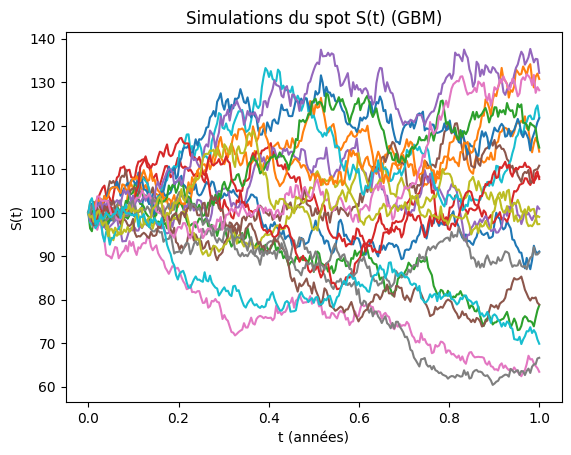

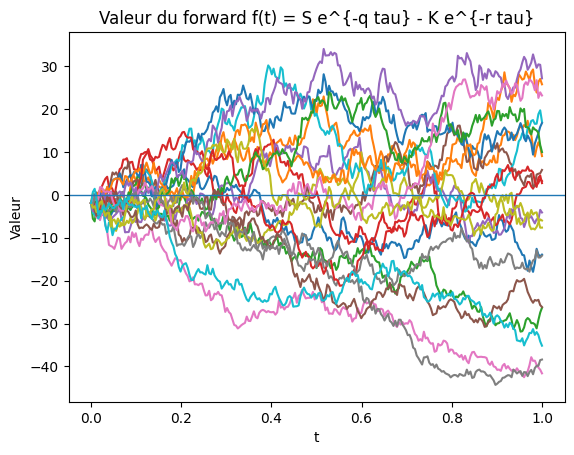

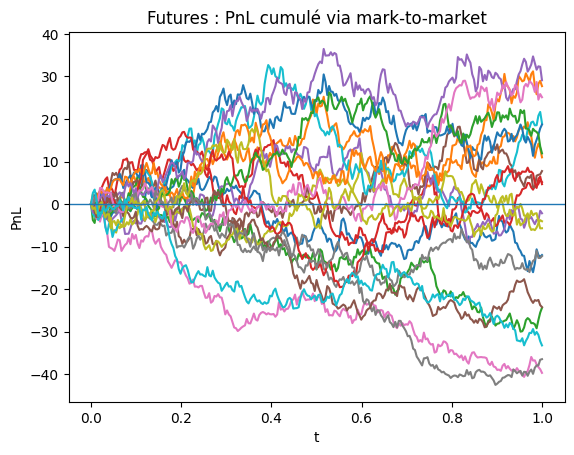

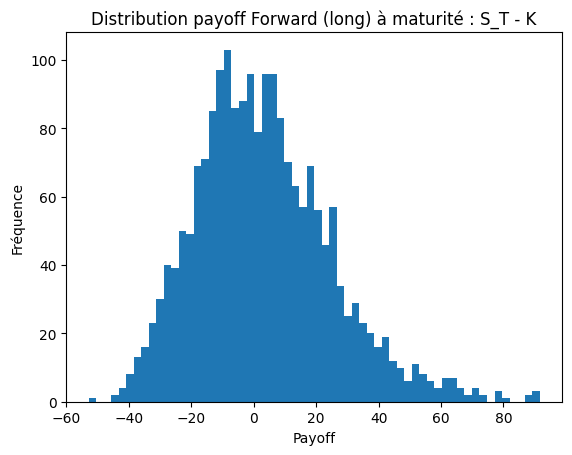

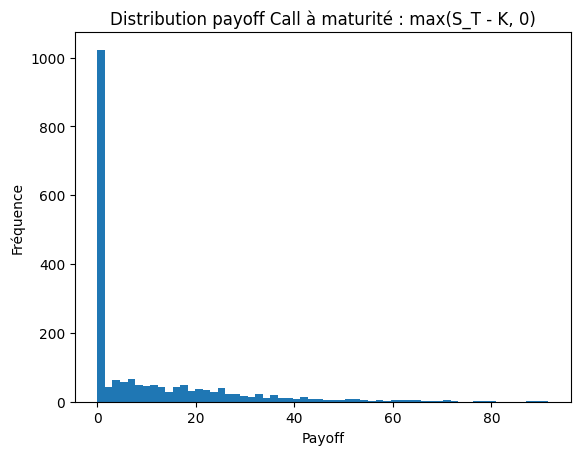

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import exp, sqrt

# -----------------------------
# 1) Simuler S_t (GBM)
# -----------------------------
def simulate_gbm_paths(S0, mu, sigma, T, n_steps, n_paths, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    S = np.zeros((n_paths, n_steps + 1))
    S[:, 0] = S0

    # increments
    Z = rng.standard_normal((n_paths, n_steps))
    for t in range(n_steps):
        S[:, t+1] = S[:, t] * np.exp((mu - 0.5 * sigma**2)*dt + sigma*np.sqrt(dt)*Z[:, t])
    times = np.linspace(0, T, n_steps + 1)
    return times, S

# -----------------------------
# 2) Forward : payoff + valeur f_t
# -----------------------------
def forward_value(S_t, K, r, q, tau):
    # tau = T - t
    return S_t * np.exp(-q * tau) - K * np.exp(-r * tau)

def forward_payoff(ST, K, position="long"):
    payoff = ST - K
    return payoff if position == "long" else -payoff

# -----------------------------
# 3) Futures : mark-to-market (approx)
# -----------------------------
def futures_price_from_spot(S_t, r, q, tau):
    return S_t * np.exp((r - q) * tau)

def futures_mtm_pnl(F_path, contract_size=1.0):
    # daily (step) cashflows: ΔF * size
    dF = np.diff(F_path, axis=1)
    cashflows = dF * contract_size
    # cumulative PnL over time (starting at 0)
    pnl = np.cumsum(cashflows, axis=1)
    pnl = np.concatenate([np.zeros((pnl.shape[0], 1)), pnl], axis=1)
    return pnl

# -----------------------------
# 4) Option pricing : Monte Carlo (risk-neutral)
# -----------------------------
def mc_european_option_price(S0, K, r, q, sigma, T, n_paths=200_000, option_type="call", seed=123):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n_paths)
    # risk-neutral drift = r - q
    ST = S0 * np.exp((r - q - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)

    if option_type == "call":
        payoff = np.maximum(ST - K, 0.0)
    else:
        payoff = np.maximum(K - ST, 0.0)

    price = np.exp(-r*T) * payoff.mean()
    return price

# -----------------------------
# Démo paramétrable
# -----------------------------
S0 = 100
mu = 0.08       # drift "réel"
sigma = 0.20
r = 0.03
q = 0.00
T = 1.0
n_steps = 252
n_paths = 2000

K = 105
contract_size = 1.0

times, S = simulate_gbm_paths(S0, mu, sigma, T, n_steps, n_paths)

# Forward value along each path
taus = T - times
FWD_value = np.zeros_like(S)
for i, tau in enumerate(taus):
    FWD_value[:, i] = forward_value(S[:, i], K, r, q, tau)

# Futures price path (approx from spot)
FUT = np.zeros_like(S)
for i, tau in enumerate(taus):
    FUT[:, i] = futures_price_from_spot(S[:, i], r, q, tau)

FUT_pnl = futures_mtm_pnl(FUT, contract_size=contract_size)

# Payoffs at maturity
ST = S[:, -1]
fwd_payoff = forward_payoff(ST, K, position="long")
call_payoff = np.maximum(ST - K, 0.0)
put_payoff = np.maximum(K - ST, 0.0)

# Option price (MC risk-neutral)
call_price_mc = mc_european_option_price(S0, K, r, q, sigma, T, option_type="call")
put_price_mc  = mc_european_option_price(S0, K, r, q, sigma, T, option_type="put")

print(f"MC Call price ~ {call_price_mc:.4f}")
print(f"MC Put  price ~ {put_price_mc:.4f}")

# -----------------------------
# Graphiques "Hull-friendly"
# -----------------------------
# 1) Quelques trajectoires du spot
plt.figure()
for i in range(20):
    plt.plot(times, S[i])
plt.title("Simulations du spot S(t) (GBM)")
plt.xlabel("t (années)")
plt.ylabel("S(t)")
plt.show()

# 2) Valeur du forward f(t) sur quelques trajectoires
plt.figure()
for i in range(20):
    plt.plot(times, FWD_value[i])
plt.title("Valeur du forward f(t) = S e^{-q tau} - K e^{-r tau}")
plt.xlabel("t")
plt.ylabel("Valeur")
plt.axhline(0, linewidth=1)
plt.show()

# 3) PnL mark-to-market futures (cumulé)
plt.figure()
for i in range(20):
    plt.plot(times, FUT_pnl[i])
plt.title("Futures : PnL cumulé via mark-to-market")
plt.xlabel("t")
plt.ylabel("PnL")
plt.axhline(0, linewidth=1)
plt.show()

# 4) Histogrammes des payoffs à maturité
plt.figure()
plt.hist(fwd_payoff, bins=60)
plt.title("Distribution payoff Forward (long) à maturité : S_T - K")
plt.xlabel("Payoff")
plt.ylabel("Fréquence")
plt.show()

plt.figure()
plt.hist(call_payoff, bins=60)
plt.title("Distribution payoff Call à maturité : max(S_T - K, 0)")
plt.xlabel("Payoff")
plt.ylabel("Fréquence")
plt.show()